In [25]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
raw_data_folder = "../data/Raw_data/"
processed_data_folder = "../data/Processed_data/"
df = pd.read_csv(raw_data_folder+"healthcare-dataset-stroke-data.csv")
df.head()



,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [26]:
df.isna().sum()


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [27]:

median = df["bmi"].median()
mean = df["bmi"].mean()
print(median)
print(mean)
df["bmi"] = df["bmi"].fillna(median)
df.isna().sum()
df.head()

28.1
28.893236911794666


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [28]:
print(df["gender"].unique())
print(df["hypertension"].unique())
print(df["heart_disease"].unique())
print(df["ever_married"].unique())
print(df["work_type"].unique())
print(df["smoking_status"].unique())
print(df["Residence_type"].unique())
print(df["stroke"].unique())


# duplicates?
print("Duplicates rows:", df.duplicated().sum())



['Male' 'Female' 'Other']
[0 1]
[1 0]
['Yes' 'No']
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
['formerly smoked' 'never smoked' 'smokes' 'Unknown']
['Urban' 'Rural']
[1 0]
Duplicates rows: 0


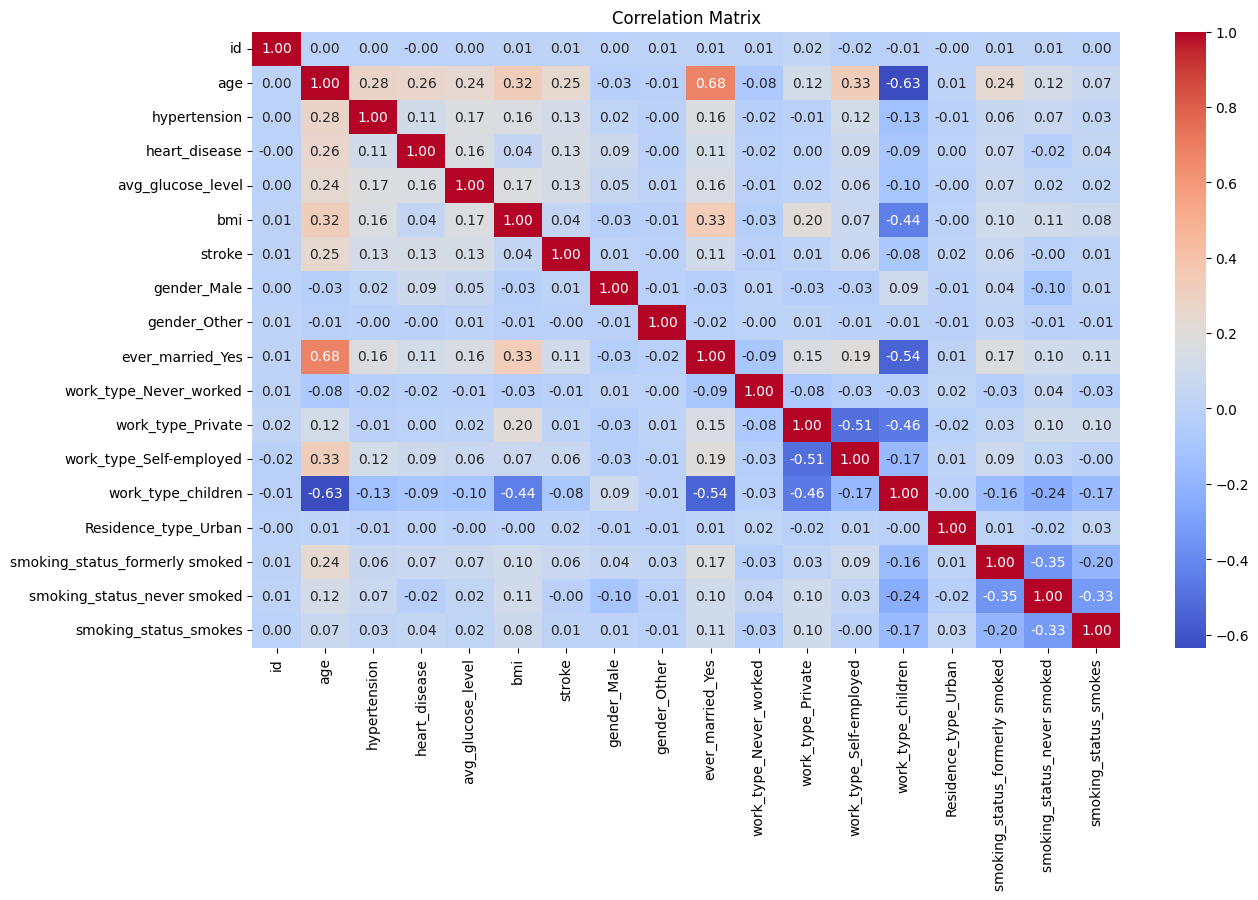

In [29]:
# Convert categorical variables into numerical ones using one-hot encoding
#pd.get_dummies creates new columns for each category in the categorical variables
#drop_first=True avoids the dummy variable trap by dropping the first category in each variable
#dummy variables for all categorical columns because correlation matrix requires numerical input
#store the new dataframe with encoded variables in df_encoded
df_encoded = pd.get_dummies(df, drop_first=True)

# Compute the correlation matrix df_encoded.corr() computes the pairwise correlation of all columns in the dataframe
correlation_matrix = df_encoded.corr()

# Plot the correlation matrix using seaborn heatmap
plt.figure(figsize=(14,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [30]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


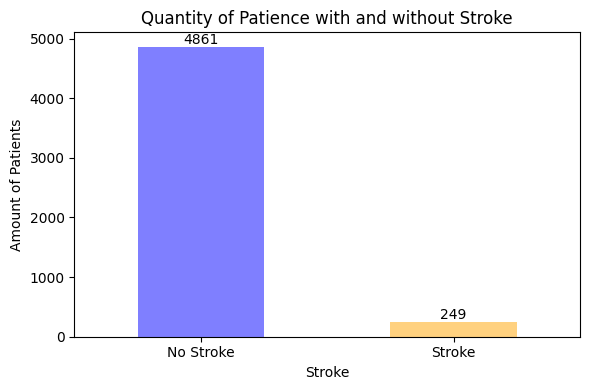

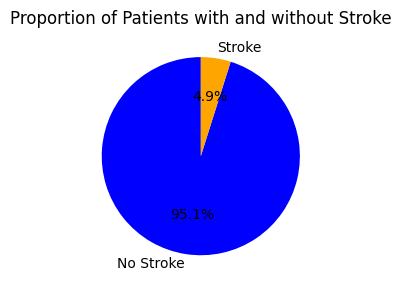

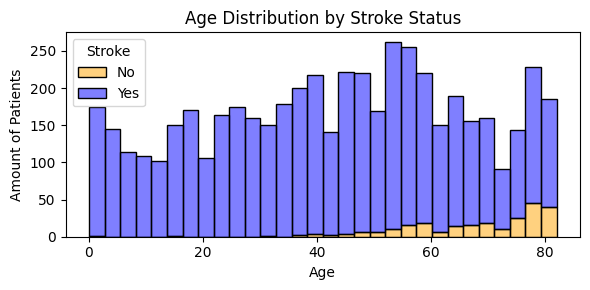

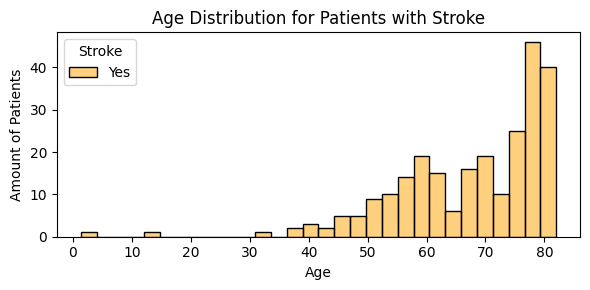

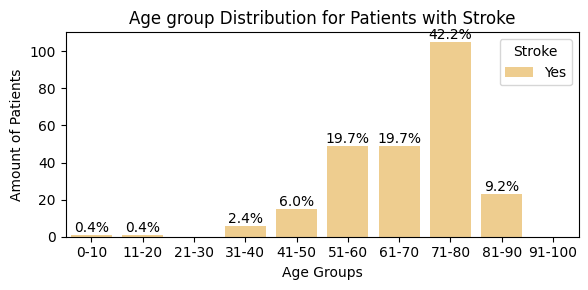

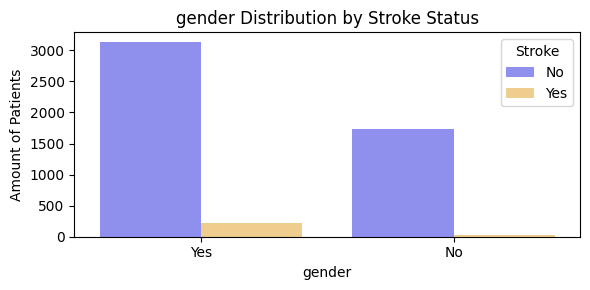

              count       mean  median        std    min   max
ever_married                                                  
No             1757  22.014229    18.0  18.474467   0.08  82.0
Yes            3353  54.342082    54.0  15.527678  18.00  82.0


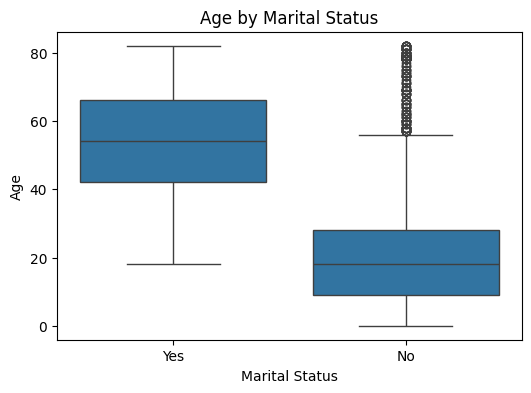

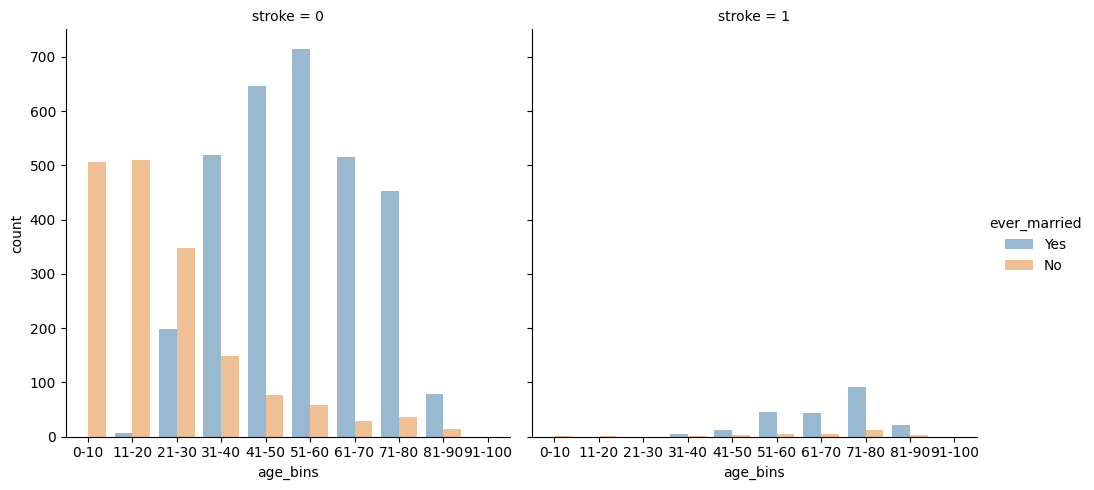

In [32]:
plt.figure(figsize=(6,4))
#next we plot a bar chart to see the quantity of patients with and without stroke, the quantity
#df.value_counts('stroke') means we are counting the number of occurrences of each value in the stroke column, plot(kind='bar') means we are plotting a bar chart, color= ["blue", "orange"] means we are using blue for no stroke and orange for stroke, alpha=0.5 means we are setting the transparency of the bars to 50%
df.value_counts('stroke').plot(kind='bar', color= ["blue", "orange"], alpha=0.5)
plt.xticks([0,1], ['No Stroke', 'Stroke'], rotation=0)
plt.title('Quantity of Patience with and without Stroke') 
plt.xlabel('Stroke')
plt.ylabel('Amount of Patients')
plt.tight_layout()

#plt.gca() means "get current axis" and containers[0] refers to the first set of bars in the bar plot
plt.bar_label(plt.gca().containers[0], label_type='edge')
plt.show()

plt.figure(figsize=(6,3))
#Pie chart for proportion of patients with and without stroke
plt.title('Proportion of Patients with and without Stroke')
#aoutopct shows percentage
plt.pie(df['stroke'].value_counts(), labels=['No Stroke', 'Stroke'], autopct='%1.1f%%', colors= ["blue", "orange"], startangle=90, shadow=False)
plt.tight_layout()
plt.show()
# Filter the dataframe for stroke = 1
stroke_df = df[df['stroke']==1]

# Histogram to see distribution of age with respect to stroke
plt.figure(figsize=(6,3))
# data=df means we are using the dataframe df, x="age" means we are plotting the age column, hue="stroke" means we are coloring the histogram based on stroke status, multiple='stack' means we are stacking the bars for each stroke status, palette=["blue", "orange"] means we are using blue for no stroke and orange for stroke, bins=30 means we are dividing the age range into 30 bins, alpha=0.5 means we are setting the transparency of the bars to 50%
sns.histplot(data=df, x="age", hue="stroke", multiple='stack', palette=["blue", "orange"], bins=30, alpha=0.5)
plt.title('Age Distribution by Stroke Status')
plt.xlabel('Age')
plt.legend(title='Stroke', loc='upper left', labels=['No', 'Yes'])
plt.ylabel('Amount of Patients')
plt.tight_layout()
plt.show()

# Histogram for age distribution with respect to stroke
plt.figure(figsize=(6,3))
sns.histplot(data=stroke_df, x="age", hue="stroke", palette=["orange"], bins=30, alpha=0.5)
plt.title('Age Distribution for Patients with Stroke')
plt.xlabel('Age')

plt.legend(title='Stroke', loc='upper left', labels=['Yes'])
plt.ylabel('Amount of Patients')
plt.tight_layout()
plt.show()

# Create BMI categories
df['age_bins'] = pd.cut(
    df['age'],
    bins=[-float('inf'), 10, 20, 30, 40 ,50 ,60 ,70 ,80 , 90, float('inf')],
    labels=['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100'])
# Plot the distribution of glucose categories for patients with stroke
plt.figure(figsize=(6, 3))
sns.countplot(data=stroke_df, x='age_bins', hue='stroke', palette=["orange"], alpha=0.5)
plt.title('Age group Distribution for Patients with Stroke')
plt.xlabel('Age Groups')
plt.legend(title='Stroke', loc='upper right', labels=['Yes'])
plt.ylabel('Amount of Patients')
# Calculate total number of patients with stroke
total = stroke_df['age_bins'].value_counts().sum()
# Add percentage labels on top of the bars, by calculating the percentage of each bar relative to the total number of patients with stroke
#plt.gca() means "get current axis" and containers[0] refers to the first set of bars in the bar plot
#f'{(v/total)*100:.1f}%' means we are formatting the value v as a percentage with one decimal place
#v is each individual bar value in the bar plot
#for v in plt.gca().containers[0].datavalues means we are iterating over each bar value in the bar plot
plt.bar_label(plt.gca().containers[0], labels=[f'{(v/total)*100:.1f}%' for v in plt.gca().containers[0].datavalues], label_type='edge')
plt.tight_layout()
plt.show()


plt.figure(figsize=(6,3))
# data=df means we are using the dataframe df, x="age" means we are plotting the age column, hue="stroke" means we are coloring the histogram based on stroke status, multiple='stack' means we are stacking the bars for each stroke status, palette=["blue", "orange"] means we are using blue for no stroke and orange for stroke, bins=30 means we are dividing the age range into 30 bins, alpha=0.5 means we are setting the transparency of the bars to 50%
sns.countplot(data=df, x="ever_married", hue="stroke", palette=["blue", "orange"],  alpha=0.5)
plt.title("gender Distribution by Stroke Status")
plt.xlabel("gender")
plt.ylabel('Amount of Patients')
plt.legend(title='Stroke', loc='upper right', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

print(df.groupby('ever_married')['age'].agg(['count','mean','median','std',"min","max"]))

# boxplot
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='ever_married', y='age')
plt.title('Age by Marital Status')
plt.bar_label
plt.xlabel('Marital Status')
plt.ylabel('Age')
plt.show()

# visualize
sns.catplot(data=df, x='age_bins', hue='ever_married', col='stroke', kind='count',  alpha=0.5)
plt.show()

In [33]:
df.drop(columns=['id', 'ever_married'], inplace=True)
# Save the cleaned dataframe to a new CSV file
df.to_csv(processed_data_folder+"stroke_data_cleaned.csv", index=False)

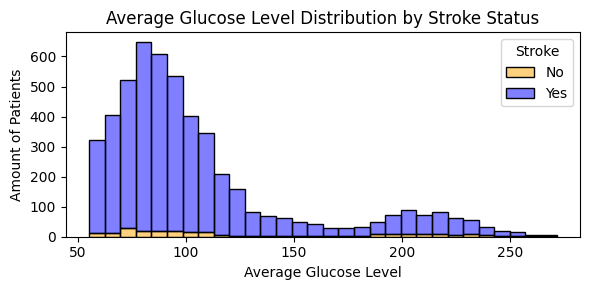

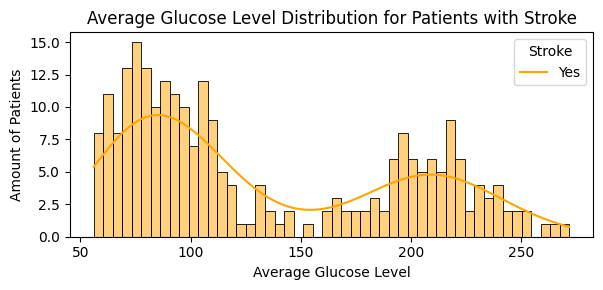

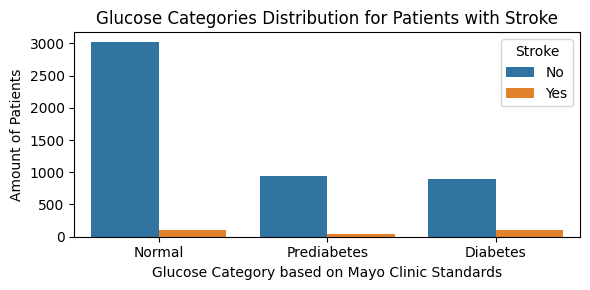

C:\Users\Christian Casas\AppData\Local\Temp\ipykernel_31960\1074532997.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stroke_df['glucose_category'] = pd.cut(


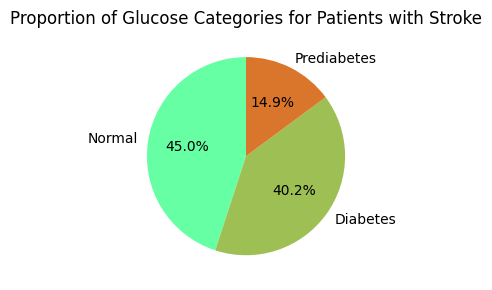

In [34]:

# Histogram to see distribution of age with respect to stroke

plt.figure(figsize=(6,3))
# data=df means we are using the dataframe df, x="age" means we are plotting the age column, hue="stroke" means we are coloring the histogram based on stroke status, multiple='stack' means we are stacking the bars for each stroke status, palette=["blue", "orange"] means we are using blue for no stroke and orange for stroke, bins=30 means we are dividing the age range into 30 bins, alpha=0.5 means we are setting the transparency of the bars to 50%
sns.histplot(data=df, x="avg_glucose_level", hue="stroke", multiple='stack', palette=["blue", "orange"], bins=30, alpha=0.5)
plt.title('Average Glucose Level Distribution by Stroke Status')
plt.xlabel('Average Glucose Level')
plt.legend(title='Stroke', loc='upper right', labels=['No', 'Yes'])
plt.ylabel('Amount of Patients')
plt.tight_layout()
plt.show()

# Histogram for average glucose level distribution with respect to stroke
plt.figure(figsize=(6,3))
#kde means kernel density estimate, it adds a smooth curve to the histogram to show the distribution of the data
sns.histplot(data=stroke_df, x="avg_glucose_level", hue="stroke", kde=True, multiple='stack', palette=["orange"], bins=50, alpha=0.5)
plt.title('Average Glucose Level Distribution for Patients with Stroke')
plt.xlabel('Average Glucose Level')
plt.legend(title='Stroke', loc='upper right', labels=['Yes'])
plt.ylabel('Amount of Patients')
plt.tight_layout()
plt.show()

# Create BMI categories
df['glucose_category'] = pd.cut(
    df['avg_glucose_level'],
    bins=[-float('inf'), 100, 125, float('inf')],
    labels=['Normal', 'Prediabetes', 'Diabetes']
)
# Plot the distribution of glucose categories for patients with stroke
plt.figure(figsize=(6, 3))
sns.countplot(data=df, x='glucose_category', hue='stroke')
plt.title('Glucose Categories Distribution for Patients with Stroke')
plt.xlabel('Glucose Category based on Mayo Clinic Standards')
plt.ylabel('Amount of Patients')
plt.legend(title='Stroke', loc='upper right', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()



# Histogram for BMI distribution with respect to stroke
# Create BMI categories
stroke_df['glucose_category'] = pd.cut(
    stroke_df['avg_glucose_level'],
    bins=[-float('inf'), 100, 125, float('inf')],
    labels=['Normal', 'Prediabetes', 'Diabetes']
)
# Plot the distribution of glucose categories for patients with stroke
#plt.figure(figsize=(6, 3))
#sns.countplot(data=stroke_df, x='glucose_category', palette=["#66B2FF", "#C98949","#933939"])
#plt.title('Glucose Categories Distribution for Patients with Stroke')
#plt.xlabel('Glucose Category based on Mayo Clinic Standards')
#plt.ylabel('Amount of Patients')
#plt.tight_layout()
#plt.show()
# Histogram for BMI distribution with respect to stroke
# Create BMI categories

# Pie chart for BMI categories for patients with stroke
glucose_category=stroke_df['glucose_category'].value_counts()
plt.figure(figsize=(6,3))
#Pie chart for proportion of patients with and without stroke
plt.title('Proportion of Glucose Categories for Patients with Stroke')
#aoutopct shows percentage
plt.pie(glucose_category, labels=glucose_category.index, autopct='%1.1f%%', colors=["#66FFA3", "#9DBF53", "#DA762B"], startangle=90, shadow=False)
plt.tight_layout()

plt.show()

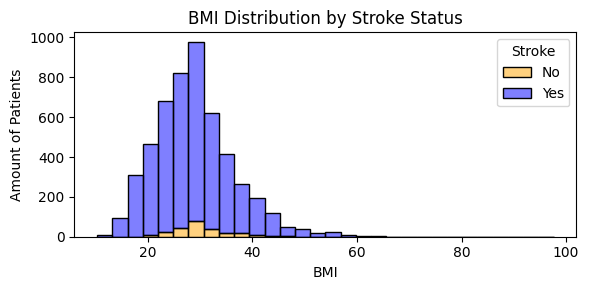

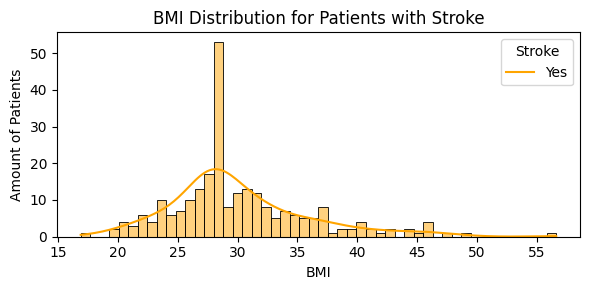

C:\Users\Christian Casas\AppData\Local\Temp\ipykernel_31960\3438300.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stroke_df['bmi_category'] = pd.cut(


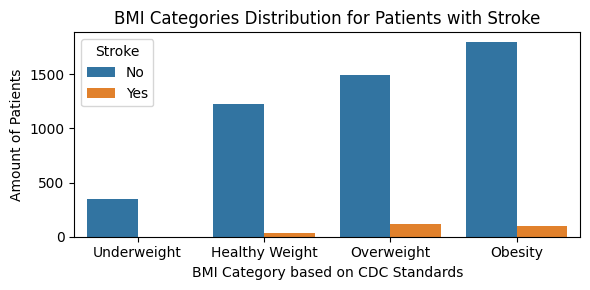

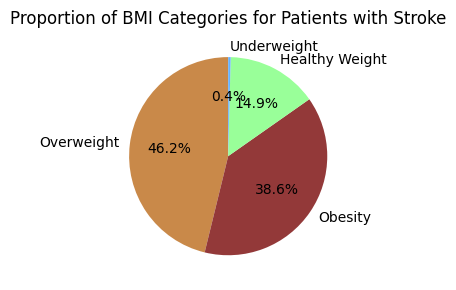

In [35]:

# Histogram to see distribution of age with respect to stroke
plt.figure(figsize=(6,3))
# data=df means we are using the dataframe df, x="age" means we are plotting the age column, hue="stroke" means we are coloring the histogram based on stroke status, multiple='stack' means we are stacking the bars for each stroke status, palette=["blue", "orange"] means we are using blue for no stroke and orange for stroke, bins=30 means we are dividing the age range into 30 bins, alpha=0.5 means we are setting the transparency of the bars to 50%
sns.histplot(data=df, x="bmi", hue="stroke", multiple='stack', palette=["blue", "orange"], bins=30, alpha=0.5)
plt.title('BMI Distribution by Stroke Status')
plt.xlabel('BMI')
plt.ylabel('Amount of Patients')
plt.legend(title='Stroke', loc='upper right', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()


# Histogram for BMI distribution with respect to stroke
plt.figure(figsize=(6,3))
#kde means kernel density estimate, it adds a smooth curve to the histogram to show the distribution of the data
sns.histplot(data=stroke_df, x="bmi", hue="stroke", kde=True, multiple='stack', palette=["orange"], bins=50, alpha=0.5)
plt.title('BMI Distribution for Patients with Stroke')
plt.xlabel('BMI')
plt.legend(title='Stroke', loc='upper right', labels=['Yes'])
plt.ylabel('Amount of Patients')
plt.tight_layout()
plt.show()
# Create BMI categories
#float('inf') means infinity and it is used to create bins that cover all possible values
#stroke_df means we are creating the bmi_category column in the stroke_df dataframe
stroke_df['bmi_category'] = pd.cut(
    stroke_df['bmi'],
    bins=[-float('inf'), 18.5, 25, 30, float('inf')],
    labels=['Underweight', 'Healthy Weight', 'Overweight', 'Obesity'])


# Create BMI categories based on CDC standards
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[-float('inf'), 18.5, 25, 30, float('inf')],
    labels=['Underweight', 'Healthy Weight', 'Overweight', 'Obesity'])

# Plot the distribution of BMI categories for patients with stroke
plt.figure(figsize=(6, 3))
sns.countplot(data=df, x='bmi_category', hue='stroke')
plt.title('BMI Categories Distribution for Patients with Stroke')
plt.xlabel('BMI Category based on CDC Standards')
plt.ylabel('Amount of Patients')
plt.legend(title='Stroke', loc='upper left', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# Plot the distribution of BMI categories for patients with stroke
#plt.figure(figsize=(6, 3))
#sns.countplot(data=stroke_df, x='bmi_category', palette=["#66B2FF", "#99FF99", "#C98949","#933939"])
#plt.title('BMI Categories Distribution for Patients with Stroke')
#plt.xlabel('BMI Category based on CDC Standards')
#plt.ylabel('Amount of Patients')
#plt.tight_layout()
#plt.show()

# Pie chart for BMI categories for patients with stroke
bmi_category=stroke_df['bmi_category'].value_counts()
plt.figure(figsize=(6,3))

#Pie chart for proportion of patients with and without stroke
plt.title('Proportion of BMI Categories for Patients with Stroke')
#aoutopct shows percentage
plt.pie(bmi_category, labels=bmi_category.index, autopct='%1.1f%%', colors=["#C98949", "#933939", "#99FF99", "#66B2FF"], startangle=90, shadow=False)
plt.tight_layout()
plt.show()

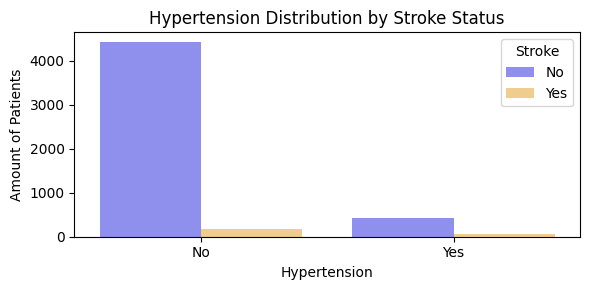

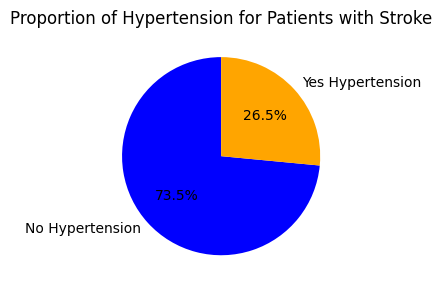

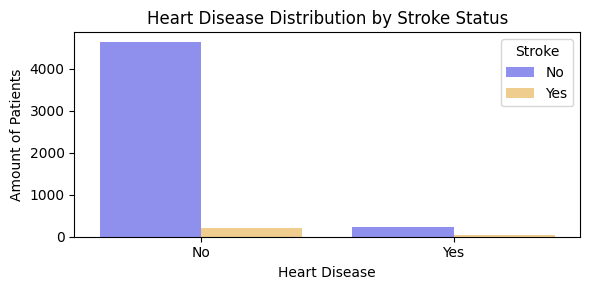

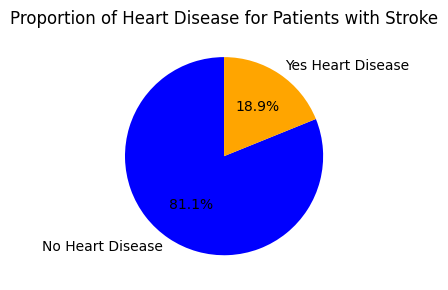

In [36]:

# Histogram to see distribution of age with respect to stroke
plt.figure(figsize=(6,3))
# data=df means we are using the dataframe df, x="age" means we are plotting the age column, hue="stroke" means we are coloring the histogram based on stroke status, multiple='stack' means we are stacking the bars for each stroke status, palette=["blue", "orange"] means we are using blue for no stroke and orange for stroke, bins=30 means we are dividing the age range into 30 bins, alpha=0.5 means we are setting the transparency of the bars to 50%
sns.countplot(data=df, x="hypertension", hue="stroke", palette=["blue", "orange"],  alpha=0.5)
plt.title('Hypertension Distribution by Stroke Status')
plt.xlabel('Hypertension')
plt.xticks([0,1], ['No', 'Yes'], rotation=0)
plt.ylabel('Amount of Patients')
plt.legend(title='Stroke', loc='upper right', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
#Pie chart for proportion of patients with and without stroke
#aoutopct shows percentage
Hyper=stroke_df['hypertension'].value_counts()
plt.pie(Hyper, labels=["No Hypertension", "Yes Hypertension"], autopct='%1.1f%%', colors= ["blue", "orange"], startangle=90, shadow=False)
plt.title('Proportion of Hypertension for Patients with Stroke')
plt.tight_layout()
plt.show()

#histogra for heart disease distribution with respect to stroke
plt.figure(figsize=(6,3))
sns.countplot(data=df, x="heart_disease", hue="stroke", palette=["blue", "orange"], alpha=0.5)
plt.title('Heart Disease Distribution by Stroke Status')
plt.xlabel('Heart Disease')
plt.xticks([0,1], ['No', 'Yes'], rotation=0)
plt.ylabel('Amount of Patients')

plt.legend(title='Stroke', loc='upper right', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()



plt.figure(figsize=(6,3))
#Pie chart for proportion of patients with and without stroke
#aoutopct shows percentage
Heart=stroke_df['heart_disease'].value_counts()
plt.pie(Heart, labels=["No Heart Disease", "Yes Heart Disease"], autopct='%1.1f%%', colors= ["blue", "orange"], startangle=90, shadow=False)
plt.title('Proportion of Heart Disease for Patients with Stroke')
plt.tight_layout()
plt.show()


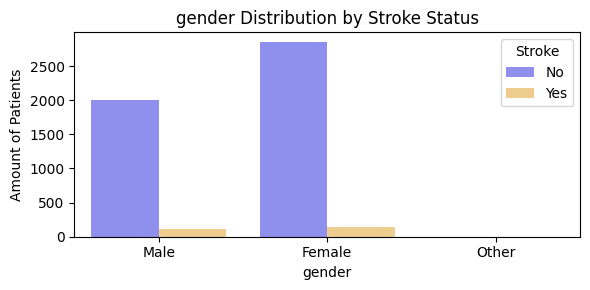

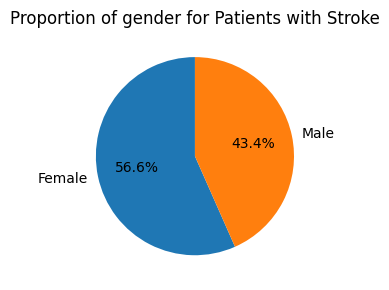

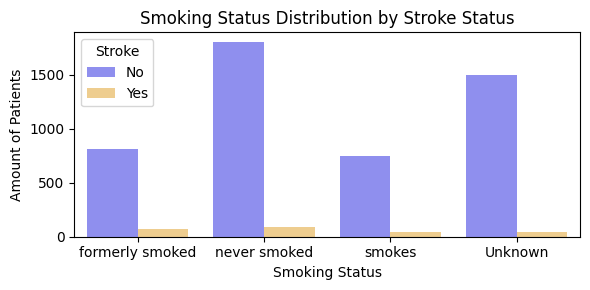

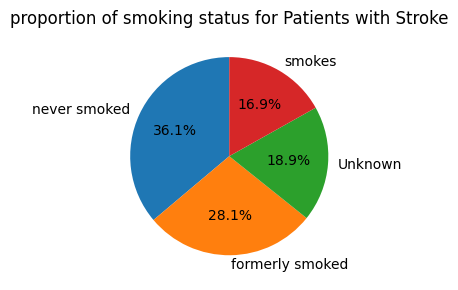

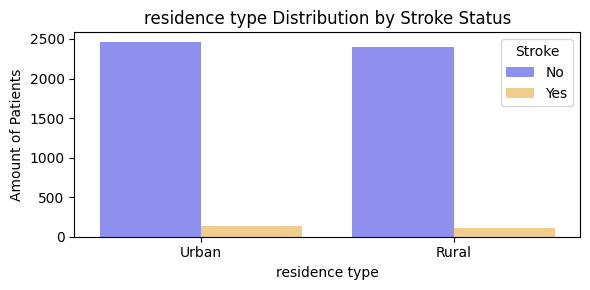

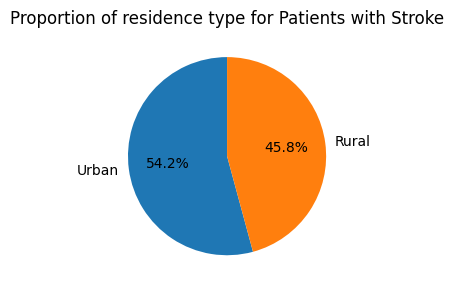

In [37]:

# Histogram to see distribution of age with respect to stroke
plt.figure(figsize=(6,3))
# data=df means we are using the dataframe df, x="age" means we are plotting the age column, hue="stroke" means we are coloring the histogram based on stroke status, multiple='stack' means we are stacking the bars for each stroke status, palette=["blue", "orange"] means we are using blue for no stroke and orange for stroke, bins=30 means we are dividing the age range into 30 bins, alpha=0.5 means we are setting the transparency of the bars to 50%
sns.countplot(data=df, x="gender", hue="stroke", palette=["blue", "orange"],  alpha=0.5)
plt.title("gender Distribution by Stroke Status")
plt.xlabel("gender")
plt.ylabel('Amount of Patients')
plt.legend(title='Stroke', loc='upper right', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
#Pie chart for proportion of patients with and without stroke
#aoutopct shows percentage
gend=stroke_df['gender'].value_counts()
plt.pie(gend, labels=gend.index, autopct='%1.1f%%', startangle=90, shadow=False)
plt.title('Proportion of gender for Patients with Stroke')
plt.tight_layout()
plt.show()

#histogra for heart disease distribution with respect to stroke
plt.figure(figsize=(6,3))
sns.countplot(data=df, x="smoking_status", hue="stroke", palette=["blue", "orange"], alpha=0.5)
plt.title('Smoking Status Distribution by Stroke Status')
plt.xlabel("Smoking Status")

plt.ylabel('Amount of Patients')

plt.legend(title='Stroke', loc='upper left', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
#Pie chart for proportion of patients with and without stroke
#aoutopct shows percentage
smoke=stroke_df['smoking_status'].value_counts()
plt.pie(smoke, labels=smoke.index, autopct='%1.1f%%', startangle=90, shadow=False)
plt.title('proportion of smoking status for Patients with Stroke')
plt.tight_layout()
plt.show()


#histogra for heart disease distribution with respect to stroke
plt.figure(figsize=(6,3))
sns.countplot(data=df, x="Residence_type", hue="stroke", palette=["blue", "orange"], alpha=0.5)
plt.title('residence type Distribution by Stroke Status')
plt.xlabel('residence type')

plt.ylabel('Amount of Patients')

plt.legend(title='Stroke', loc='upper right', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
#Pie chart for proportion of patients with and without stroke
#aoutopct shows percentage
res=stroke_df['Residence_type'].value_counts()
plt.pie(res, labels=res.index, autopct='%1.1f%%', startangle=90, shadow=False)
plt.title('Proportion of residence type for Patients with Stroke')
plt.tight_layout()
plt.show()

Accuracy: 0.9500978473581213

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



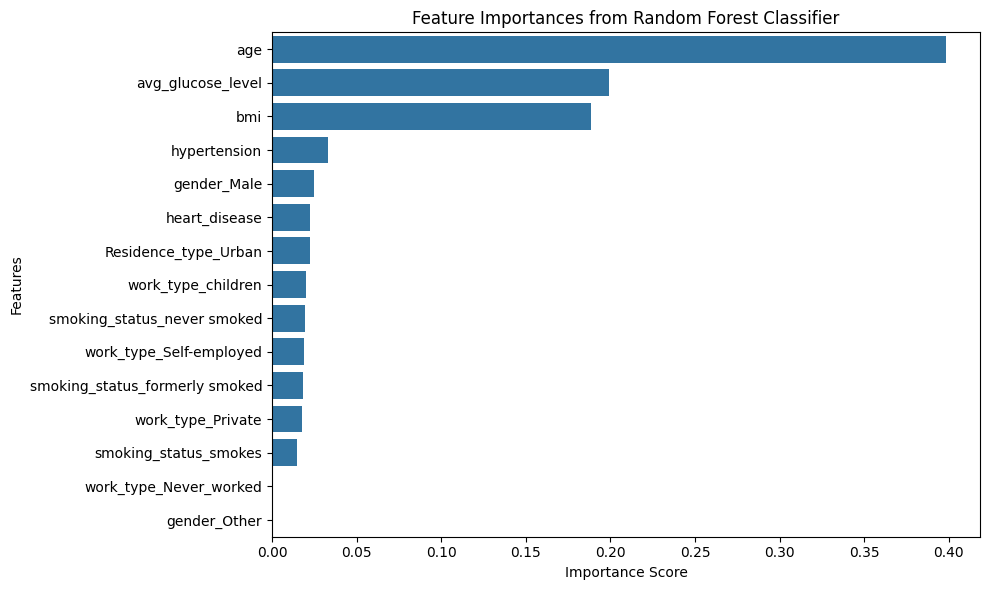

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, mean_squared_error, r2_score

# Define the features (X) and target (y)
#we drop the stroke column from the features because it is the target variable we want to predict, so we separate it from the features
x = df_encoded.drop(columns=['stroke', 'id','ever_married_Yes'])
#we assign the stroke column to the target variable y
y = df_encoded['stroke']

# Split the data into training and testing sets with stratification to maintain class distribution, stratify =y ensures that the proportion of classes in the target variable is maintained in both the training and testing sets, if we don't use stratification, the training and testing sets may have different class distributions, which can lead to biased model performance
#we choose test_size=0.2 to allocate 20% of the data for testing and 80% for training
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the Random Forest model with class_weight='balanced' to handle class imbalance

model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Train the model by fitting it to the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model by calculating accuracy and generating a classification report
#the accuracy_score function computes the ratio of correctly predicted instances to the total instances in the test set
print("Accuracy:", accuracy_score(y_test, y_pred))
#then we print the classification report which includes precision, recall, f1-score, and support for each class
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#now we are gonna check feature importance to see which features are most important for predicting stroke
feature_importances = pd.Series(model.feature_importances_, index=x.columns)
#sort the feature importances in descending order
feature_importances = feature_importances.sort_values(ascending=False)
#plot the feature importances
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()



In [53]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (scaled): {mse}")
print(f"R-squared (scaled): {r2}")

#

Mean Squared Error (scaled): 0.049902152641878667
R-squared (scaled): -0.07246913580246916


In [ ]:
#Now we are gonna predict stroke for new data points

# Define a new data point (example)
new_data = pd.DataFrame({
    'age': [80],
    'hypertension': [0],
    'heart_disease': [1],
    'avg_glucose_level': [328.69],
    'bmi': [396.6], 
    'gender_Male': [1], 
    'gender_Other': [0],
    #'ever_married_Yes': [1],
    'work_type_Never_worked': [0],
    'work_type_Private': [1],
    'work_type_Self-employed': [0],
    'work_type_children': [0],
    'Residence_type_Urban': [1],
    'smoking_status_formerly smoked': [0],
    'smoking_status_never smoked': [1],
    'smoking_status_smokes': [0]
})

# Reorder the columns of new_data to match the order of columns in X_train
new_data = new_data[X_train.columns]

# Scale the new data point using the same scaler

print("Accuracy:", accuracy_score(y_test, y_pred))
#then we print the classification report which includes precision, recall, f1-score, and support for each class
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# Predict stroke for the new data point
prediction = model.predict(new_data)
print("Predicted Stroke (1=Yes, 0=No):", prediction[0])
#now we print the confidence level of the prediction using predict_proba method, this means the probability of each class (stroke or no stroke) based on the new data point [0.97, 0.03] means the model is 97% confident that the patient will not have a stroke and 3% confident that the patient will have a stroke
print("confidence level", model.predict_proba(new_data))



Accuracy: 0.9500978473581213

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

Predicted Stroke (1=Yes, 0=No): 0
confidence level [[0.73 0.27]]


In [ ]:
threshold = 0.25

y_prob = model.predict_proba(X_test)[:, 1]
y_preda = (y_prob>threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_preda))
#then we print the classification report which includes precision, recall, f1-score, and support for each class
print("\nClassification Report:\n", classification_report(y_test, y_preda))

#recall 12% means that out of all actual stroke cases, the model correctly identifies 12% of them. This indicates that the model is missing a significant number of stroke cases, which could be critical in a healthcare context where early detection is vital.
#precision 16% means that out of all cases predicted as stroke by the model, only 16% are actually stroke cases. This low precision indicates a high rate of false positives, which could lead to unnecessary anxiety and medical interventions for patients incorrectly identified as at risk for stroke.

new_data_P = pd.DataFrame({
    'age': [100],
    'hypertension': [0],
    'heart_disease': [1],
    'avg_glucose_level': [328.69],
    'bmi': [196.6], 
    'gender_Male': [1], 
    'gender_Other': [0],
    #'ever_married_Yes': [1],
    'work_type_Never_worked': [0],
    'work_type_Private': [1],
    'work_type_Self-employed': [0],
    'work_type_children': [0],
    'Residence_type_Urban': [1],
    'smoking_status_formerly smoked': [0],
    'smoking_status_never smoked': [1],
    'smoking_status_smokes': [0]
})

# Reorder the columns of new_data to match the order of columns in X_train
new_data_P = new_data_P[X_train.columns]

# Scale the new data point using the same scaler


# Predict stroke for the new data point
prob = model.predict_proba(new_data_P)[0, 1]
pred_custom = 1 if prob > threshold else 0
print("Predicted Stroke (1=Yes, 0=No):", pred_custom)
#now we print the confidence level of the prediction using predict_proba method, this means the probability of each class (stroke or no stroke) based on the new data point [0.97, 0.03] means the model is 97% confident that the patient will not have a stroke and 3% confident that the patient will have a stroke
print("confidence level", model.predict_proba(new_data_P))

Accuracy: 0.9285714285714286

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.21      0.16      0.18        50

    accuracy                           0.93      1022
   macro avg       0.58      0.56      0.57      1022
weighted avg       0.92      0.93      0.92      1022

Predicted Stroke (1=Yes, 0=No): 0
confidence level [[0.75 0.25]]


number customers unique()
unique products?
avg price per product/category/order
highest sold product
highest selling month
top 10 cateogries, products, months, sellers
sales over time


K Fold cross validation
Smote


talk about stratification, balance within Random tree forest why was that used 


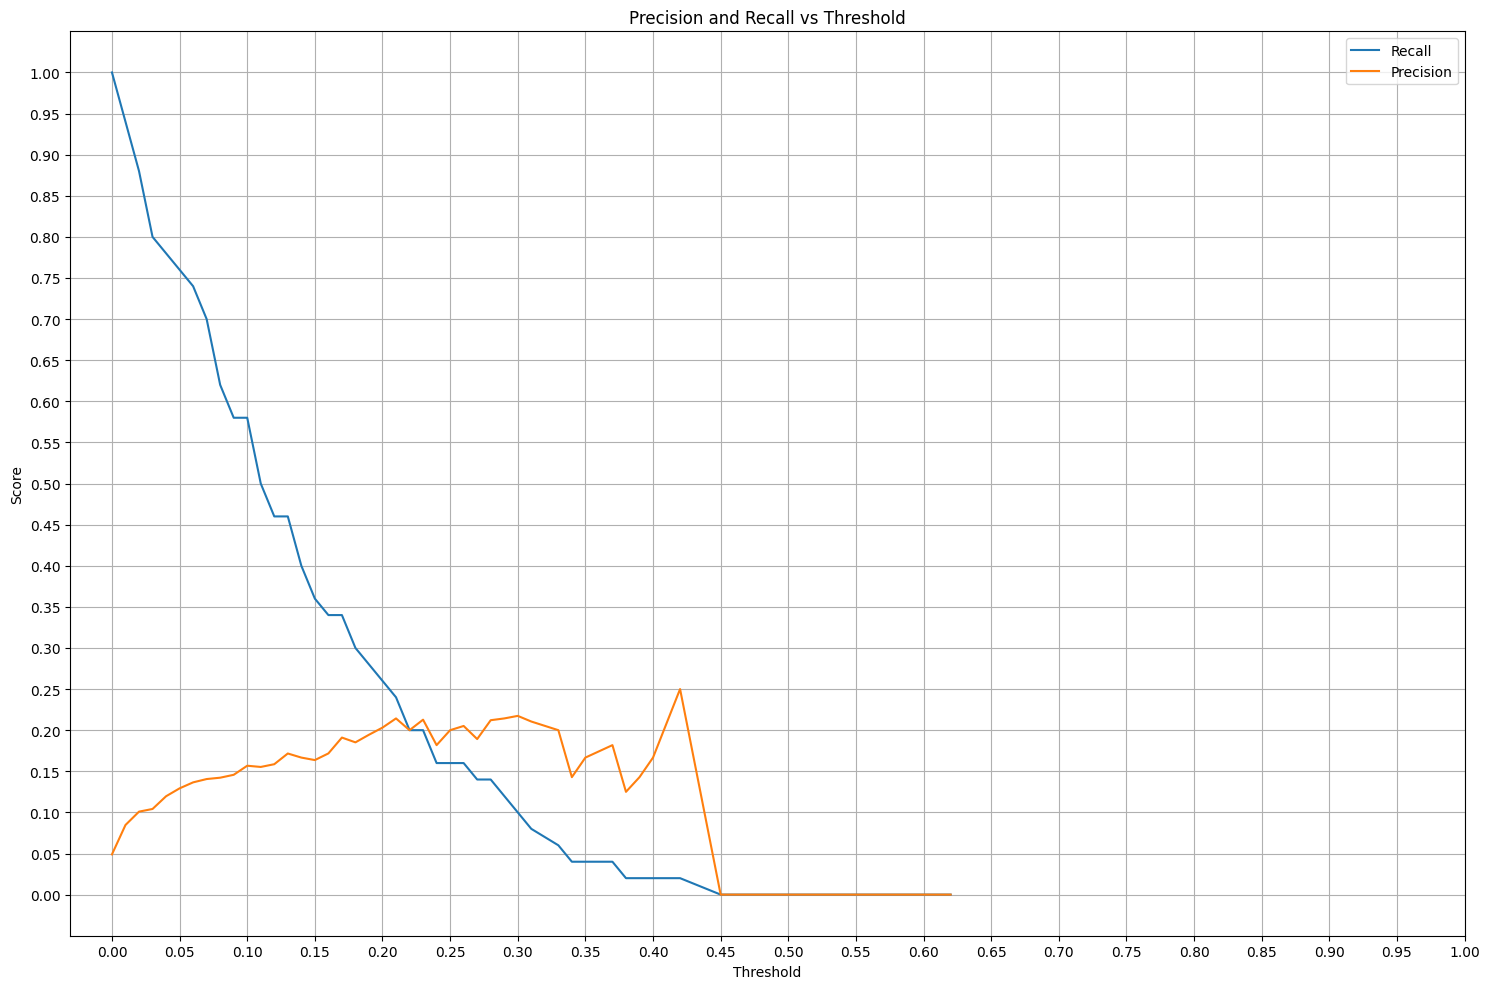

In [56]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

prec, rec, thr = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(15,10))
plt.plot(thr, rec[:-1], label='Recall')
plt.plot(thr, prec[:-1], label='Precision')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.grid()  
plt.xticks(np.arange(0, 1.05, 0.05))
plt.yticks(np.arange(0, 1.05, 0.05))
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
threshold = 0.25
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train_balanced,y_train_balanced = smote.fit_resample(X_train, y_train)
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train_balanced, y_train_balanced)



y_prob = model.predict_proba(X_test)[:, 1]
y_preda = (y_prob>threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_preda))
#then we print the classification report which includes precision, recall, f1-score, and support for each class
print("\nClassification Report:\n", classification_report(y_test, y_preda))

#recall 12% means that out of all actual stroke cases, the model correctly identifies 12% of them. This indicates that the model is missing a significant number of stroke cases, which could be critical in a healthcare context where early detection is vital.
#precision 16% means that out of all cases predicted as stroke by the model, only 16% are actually stroke cases. This low precision indicates a high rate of false positives, which could lead to unnecessary anxiety and medical interventions for patients incorrectly identified as at risk for stroke.

new_data_P = pd.DataFrame({
    'age': [100],
    'hypertension': [0],
    'heart_disease': [1],
    'avg_glucose_level': [328.69],
    'bmi': [196.6], 
    'gender_Male': [1], 
    'gender_Other': [0],
    #'ever_married_Yes': [1],
    'work_type_Never_worked': [0],
    'work_type_Private': [1],
    'work_type_Self-employed': [0],
    'work_type_children': [0],
    'Residence_type_Urban': [1],
    'smoking_status_formerly smoked': [0],
    'smoking_status_never smoked': [1],
    'smoking_status_smokes': [0]
})

# Reorder the columns of new_data to match the order of columns in X_train
new_data_P = new_data_P[X_train_balanced.columns]

# Scale the new data point using the same scaler



# Predict stroke for the new data point
prob = model.predict_proba(new_data_P)[0, 1]
pred_custom = 1 if prob > threshold else 0
print("Predicted Stroke (1=Yes, 0=No):", pred_custom)
#now we print the confidence level of the prediction using predict_proba method, this means the probability of each class (stroke or no stroke) based on the new data point [0.97, 0.03] means the model is 97% confident that the patient will not have a stroke and 3% confident that the patient will have a stroke
print("confidence level", model.predict_proba(new_data_P))
print("threshold:", threshold)

Accuracy: 0.8414872798434442

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.86      0.91       972
           1       0.13      0.40      0.20        50

    accuracy                           0.84      1022
   macro avg       0.55      0.63      0.56      1022
weighted avg       0.92      0.84      0.88      1022

Predicted Stroke (1=Yes, 0=No): 1
confidence level [[0.29 0.71]]
threshold: 0.25


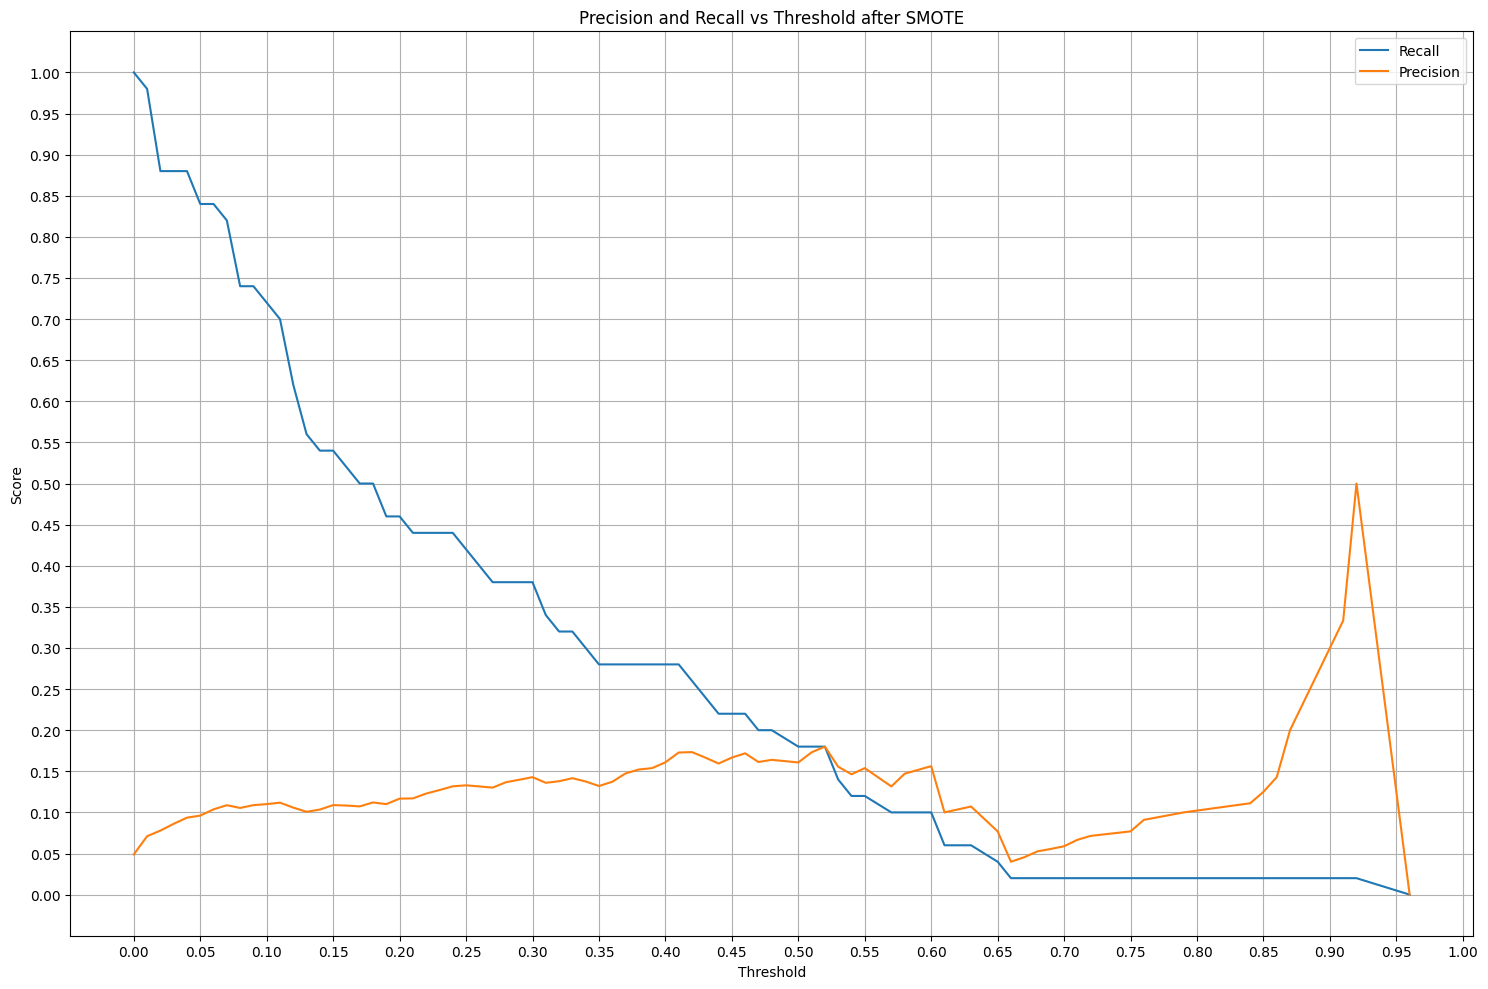

In [58]:
prec, rec, thr = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(15,10))
plt.plot(thr, rec[:-1], label='Recall')
plt.plot(thr, prec[:-1], label='Precision')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold after SMOTE")
plt.grid()
plt.xticks(np.arange(0, 1.05, 0.05))
plt.yticks(np.arange(0, 1.05, 0.05))
plt.legend()
plt.tight_layout()


plt.show()

Fold 1 - Accuracy: 0.837573385518591

Fold 1 - Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.86      0.91       486
           1       0.13      0.40      0.19        25

    accuracy                           0.84       511
   macro avg       0.55      0.63      0.55       511
weighted avg       0.92      0.84      0.87       511

Fold 2 - Accuracy: 0.8669275929549902

Fold 2 - Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93       486
           1       0.16      0.40      0.23        25

    accuracy                           0.87       511
   macro avg       0.56      0.65      0.58       511
weighted avg       0.93      0.87      0.89       511

Fold 3 - Accuracy: 0.8336594911937377

Fold 3 - Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.86      0.91       486
           1       0.1

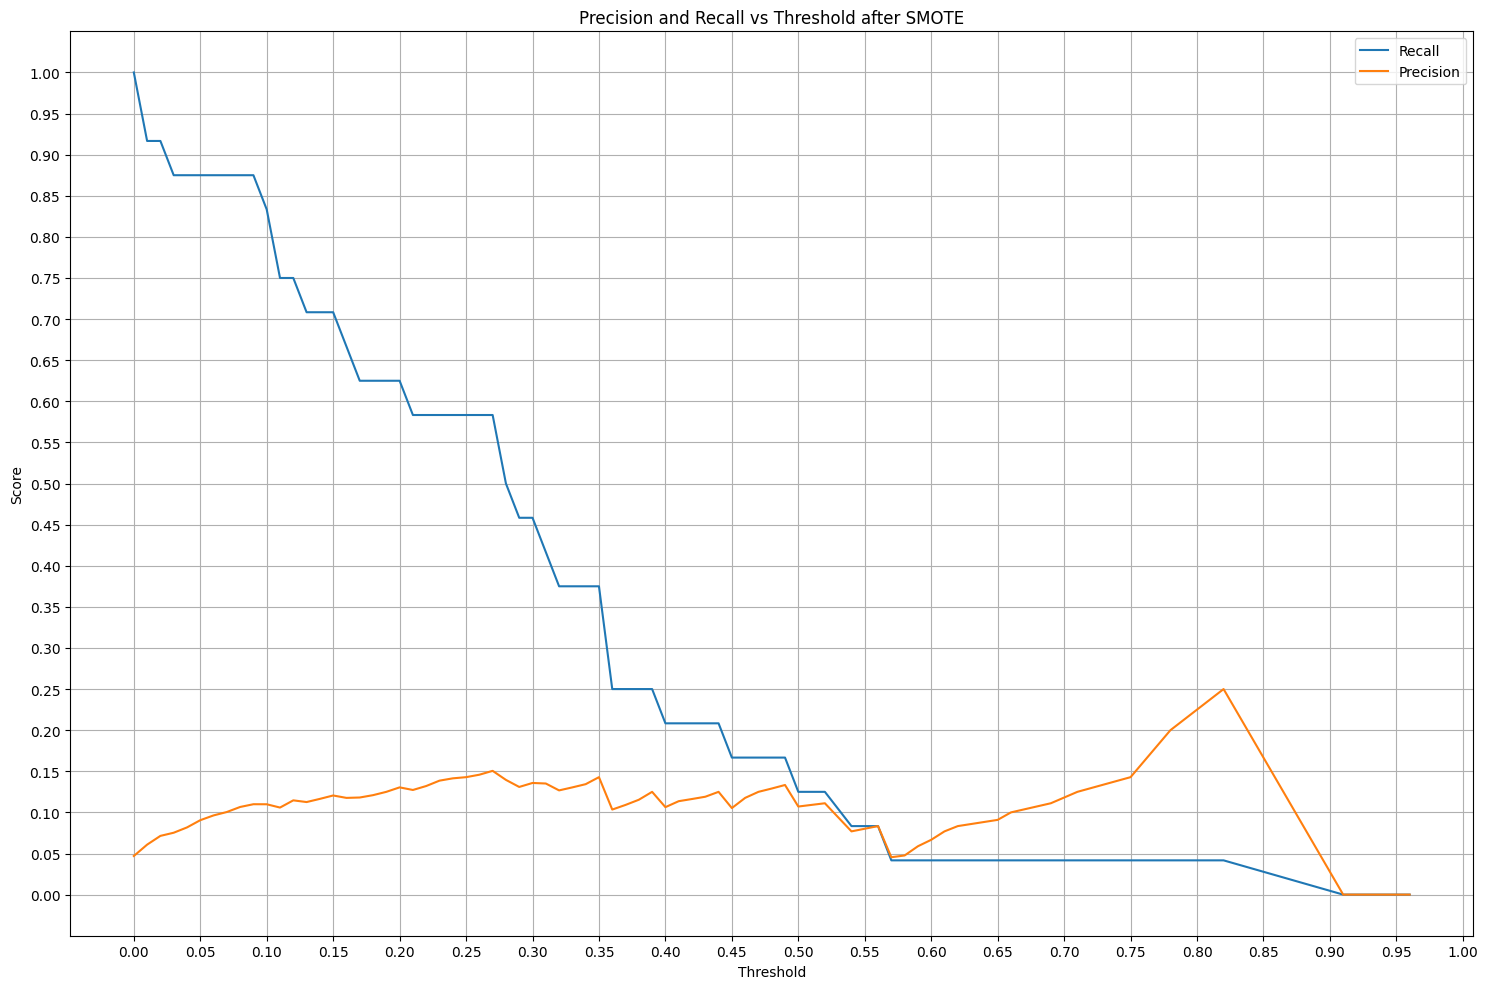

In [59]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold = 1
threshold = 0.25
#next we perform stratified k-fold cross-validation to evaluate the model's performance more robustly since the dataset is imbalanced, skf.split(x, y) generates indices to split data into training and test sets while preserving the percentage of samples for each class
for train_index, test_index in skf.split(x, y):
    #we need a for loop to iterate through each fold, train the model on the training set, and evaluate it on the test set
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    #.iloc is used to select rows by integer-location based indexing
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    
    model = RandomForestClassifier(random_state=42, class_weight='balanced')
    model.fit(X_train_balanced, y_train_balanced)
    
    y_prob = model.predict_proba(X_test)[:, 1]
    y_preda = (y_prob > threshold).astype(int)
    
    print(f"Fold {fold} - Accuracy:", accuracy_score(y_test, y_preda))
    print(f"\nFold {fold} - Classification Report:\n", classification_report(y_test, y_preda))
    fold += 1
    prec, rec, thr = precision_recall_curve(y_test, y_prob)

    
print("Fold Accuracy:", accuracy_score(y_test, y_preda))
print("\nFold - Classification Report:\n", classification_report(y_test, y_preda))

plt.figure(figsize=(15,10))
plt.plot(thr, rec[:-1], label='Recall')
plt.plot(thr, prec[:-1], label='Precision')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold after SMOTE")
plt.grid()
plt.xticks(np.arange(0, 1.05, 0.05))
plt.yticks(np.arange(0, 1.05, 0.05))
plt.legend()
plt.tight_layout()


plt.show()


Fold 1 - Accuracy: 0.8238747553816047

Fold 1 - Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.84      0.90       486
           1       0.14      0.52      0.22        25

    accuracy                           0.82       511
   macro avg       0.56      0.68      0.56       511
weighted avg       0.93      0.82      0.87       511

Fold 2 - Accuracy: 0.8356164383561644

Fold 2 - Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.86      0.91       486
           1       0.14      0.44      0.21        25

    accuracy                           0.84       511
   macro avg       0.55      0.65      0.56       511
weighted avg       0.93      0.84      0.87       511

Fold 3 - Accuracy: 0.7984344422700587

Fold 3 - Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.81      0.88       486
           1       0.

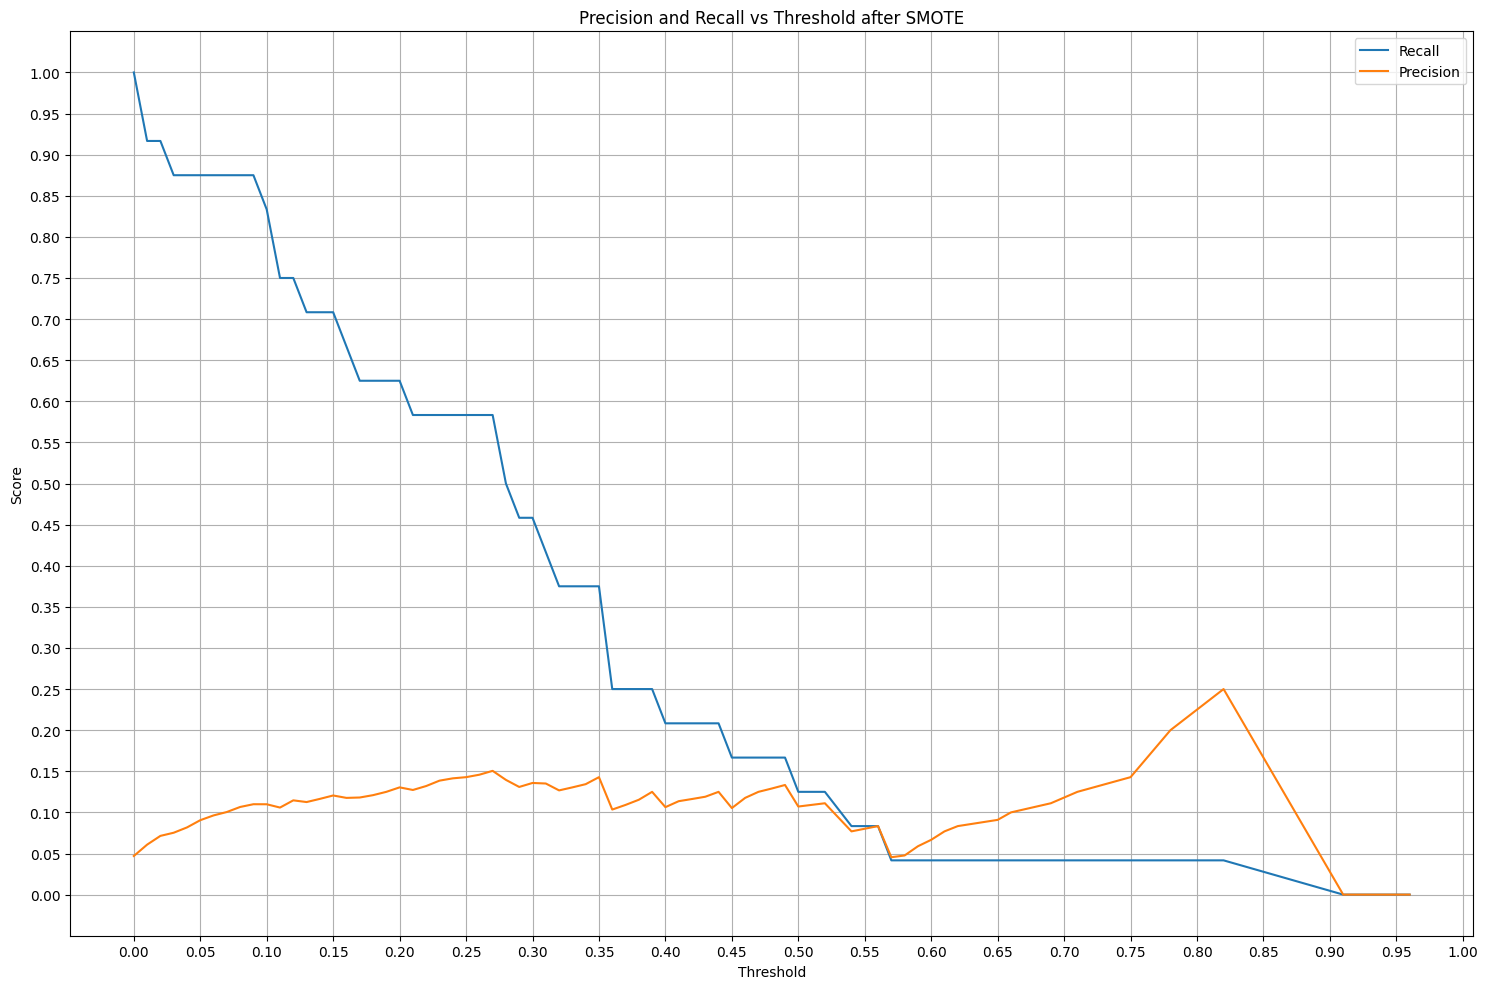

In [ ]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold = 1
threshold = 0.2
#next we perform stratified k-fold cross-validation to evaluate the model's performance more robustly since the dataset is imbalanced, skf.split(x, y) generates indices to split data into training and test sets while preserving the percentage of samples for each class
for train_index, test_index in skf.split(x, y):
    #we need a for loop to iterate through each fold, train the model on the training set, and evaluate it on the test set
    X_train, X_test = x.iloc[train_index], x.iloc[test_index]
    #.iloc is used to select rows by integer-location based indexing
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    
    model = RandomForestClassifier(random_state=42, class_weight='balanced')
    model.fit(X_train_balanced, y_train_balanced)
    
    y_prob = model.predict_proba(X_test)[:, 1]
    y_preda = (y_prob > threshold).astype(int)
    
    print(f"Fold {fold} - Accuracy:", accuracy_score(y_test, y_preda))
    print(f"\nFold {fold} - Classification Report:\n", classification_report(y_test, y_preda))
    fold += 1

    



In [ ]:
import joblib

smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(x, y)

#n_estimators increases the precision probability by balancing better the weights also increases the variation of the probability %
#addion min_samples_leaf=5 helps us with smoother probability and lower overfiting, thus better recall/precision
final_model = RandomForestClassifier(n_estimators=1000, min_samples_leaf=5, random_state=42, class_weight='balanced')
final_model.fit(X_bal, y_bal)
print("Fold Accuracy:", accuracy_score(y_test, y_preda))
print("\nFold - Classification Report:\n", classification_report(y_test, y_preda))
prec, rec, thr = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(15,10))
plt.plot(thr, rec[:-1], label='Recall')
plt.plot(thr, prec[:-1], label='Precision')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold after SMOTE")
plt.grid()
plt.xticks(np.arange(0, 1.05, 0.05))
plt.yticks(np.arange(0, 1.05, 0.05))
plt.legend()
plt.tight_layout()
plt.show()
joblib.dump(final_model, "random_forest_model.joblib")


Fold Accuracy: 0.7925636007827789

Fold - Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.80      0.88       487
           1       0.13      0.58      0.21        24

    accuracy                           0.79       511
   macro avg       0.55      0.69      0.54       511
weighted avg       0.94      0.79      0.85       511



['random_forest_model.joblib']

In [69]:


new_data_P = pd.DataFrame({
    'age': [52],
    'hypertension': [0],
    'heart_disease': [0],
    'avg_glucose_level': [70.69],
    'bmi': [22.6], 
    'gender_Male': [1], 
    'gender_Other': [0],
    #'ever_married_Yes': [0],
    'work_type_Never_worked': [0],
    'work_type_Private': [1],
    'work_type_Self-employed': [0],
    'work_type_children': [0],
    'Residence_type_Urban': [1],
    'smoking_status_formerly smoked': [0],
    'smoking_status_never smoked': [1],
    'smoking_status_smokes': [0]
})

# Reorder the columns of new_data to match the order of columns in X_train
new_data_P = new_data_P[X_train_balanced.columns]

# Scale the new data point using the same scaler
# Predict stroke for the new data point
Final_Prob = final_model.predict_proba(new_data_P).round(4)
prob = final_model.predict_proba(new_data_P)[0, 1]
pred_custom = 1 if prob > threshold else 0
print("Predicted Stroke (1=Yes, 0=No):", pred_custom)
#now we print the confidence level of the prediction using predict_proba method, this means the probability of each class (stroke or no stroke) based on the new data point [0.97, 0.03] means the model is 97% confident that the patient will not have a stroke and 3% confident that the patient will have a stroke
print("confidence level", Final_Prob)
print("threshold:", threshold)



Predicted Stroke (1=Yes, 0=No): 1
confidence level [[0.5964 0.4036]]
threshold: 0.2


AUC: 0.767539356605065


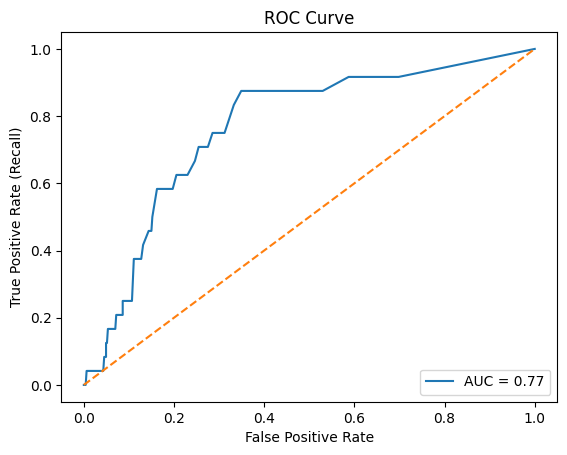

In [63]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class (stroke = 1)
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

# Plot ROC curve 
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line
plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()